In [21]:
from torchvision.transforms import (
    Compose, Resize, ToTensor, Normalize, ConvertImageDtype, RandomRotation, RandomHorizontalFlip
)
from torch import nn
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import gc

import torch
import pandas as pd
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [29]:
def get_trainer():
    import sys
    project_root = Path.cwd().resolve().parent
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
    from base import TorchTrainer
    return TorchTrainer

In [15]:
DATA_DIR = Path('../data/cifar-10')
train_labels = pd.read_csv(DATA_DIR / 'trainLabels.csv')
test_labels = pd.read_csv(DATA_DIR / 'sampleSubmission.csv')
train_folder = DATA_DIR / 'train'
test_folder = DATA_DIR / 'test'

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


def get_image_path(labels, folder):
    path_labels = []
    for index, row in labels.iterrows():
        image_id = row['id']
        image_label = row['label']
        image_path = folder / f"{image_id}.png"
        path_labels.append((image_path, image_label))
    return path_labels


train_image_paths = get_image_path(train_labels, train_folder)
test_image_paths = get_image_path(test_labels, test_folder)

ratio = 0.9
train_df = pd.DataFrame(
    train_image_paths[:int(len(train_image_paths) * ratio)],
    columns=['image_path', 'label'])
val_df = pd.DataFrame(
    train_image_paths[int(len(train_image_paths) * ratio):],
    columns=['image_path', 'label'])
test_df = pd.DataFrame(test_image_paths, columns=['image_path', 'label'])

In [24]:
class Cifar10Dataset(Dataset):
    df_map = {
        'train': train_df,
        'val': val_df,
        'test': test_df
    }

    label_to_idx = {label: idx for idx, label in enumerate(class_names)}
    idx_to_label = {idx: label for idx, label in enumerate(class_names)}

    def __init__(self, model="train", transform=None):
        self.data = self.df_map[model]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path, label = self.data.iloc[idx]
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.label_to_idx[label]
        return image, label


IMG_SIZE = 32


def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False)

    mean = 0.0
    std = 0.0
    total_images = 0

    for images, _ in tqdm(loader, desc="Computing mean/std"):
        # batch size (the last batch can have smaller size)
        batch_samples = images.size(0)
        # reshape to (batch_size, channels, width*height)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)  # sum of means for each channel
        std += images.std(2).sum(0)  # sum of stds for each channel
        total_images += batch_samples

    mean /= total_images
    std /= total_images

    return mean.tolist(), std.tolist()


mean, std = compute_mean_std(
    Cifar10Dataset(model='train', transform=Compose([
        Resize(IMG_SIZE),
        ToTensor(),
    ])))


# 图像增强可以增加训练数据的多样性，帮助模型更好地泛化，从而提高模型的性能和鲁棒性。
# 1. 随机旋转图像：通过随机旋转图像，可以模拟不同的拍摄角度和姿态，使模型更好地适应各种视角。
# 2. 随机水平翻转图像：通过随机水平翻转图像，可以模拟左右对称的物体，使模型更好地适应不同的方向和姿态。
# 3. 随机裁剪图像：通过随机裁剪图像，可以模拟不同的物体位置和大小，使模型更好地适应各种场景和物体尺寸。
# 4. 随机调整图像亮度、对比度和饱和度：通过随机调整图像的亮度、对比度和饱和度，可以模拟不同的光照条件和环境，使模型更好地适应各种光照变化。
# 5. 随机添加噪声：通过随机添加噪声，可以模拟不同的图像质量和干扰，使模型更好地适应各种图像质量和干扰情况。
transform_train = Compose([
    Resize(IMG_SIZE),
    # 随机旋转图像，旋转角度在-40到40度之间
    RandomRotation(40),
    # 随机水平翻转图像，翻转概率为0.5
    RandomHorizontalFlip(),
    ToTensor(),
    Normalize(mean=mean, std=std)
])

transform_eval = Compose([
    Resize(IMG_SIZE),
    ToTensor(),
    Normalize(mean=mean, std=std)
])

Computing mean/std: 100%|██████████| 704/704 [00:14<00:00, 47.63it/s]


In [25]:
train_ds = Cifar10Dataset(model='train', transform=transform_train)
val_ds = Cifar10Dataset(model='val', transform=transform_eval)
test_ds = Cifar10Dataset(model='test', transform=transform_eval)

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [27]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(
                in_channels=3, out_channels=128, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(
                in_channels=128, out_channels=128, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(
                in_channels=128, out_channels=256, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(
                in_channels=256, out_channels=256, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(
                in_channels=256, out_channels=512, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.Conv2d(
                in_channels=512, out_channels=512, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)
    
print(sum(p.numel() for p in CNN().parameters()))

4647178


Epoch 1/20 | train_loss=1.4940 | train_acc=0.4513 | train_balanced_acc=0.4514 | train_f1_macro=0.4470 | val_loss=1.1835 | val_acc=0.5736 | val_balanced_acc=0.5732 | val_f1_macro=0.5593 | lr=0.0010 | epoch_seconds=36.1700


Epoch 2/20 | train_loss=1.1140 | train_acc=0.6021 | train_balanced_acc=0.6021 | train_f1_macro=0.6001 | val_loss=0.9663 | val_acc=0.6616 | val_balanced_acc=0.6622 | val_f1_macro=0.6581 | lr=0.0010 | epoch_seconds=35.1132


Epoch 3/20 | train_loss=0.9098 | train_acc=0.6798 | train_balanced_acc=0.6798 | train_f1_macro=0.6790 | val_loss=0.7292 | val_acc=0.7460 | val_balanced_acc=0.7460 | val_f1_macro=0.7453 | lr=0.0010 | epoch_seconds=35.8225


Epoch 4/20 | train_loss=0.7716 | train_acc=0.7335 | train_balanced_acc=0.7335 | train_f1_macro=0.7330 | val_loss=0.6281 | val_acc=0.7810 | val_balanced_acc=0.7814 | val_f1_macro=0.7826 | lr=0.0010 | epoch_seconds=35.8029


Epoch 5/20 | train_loss=0.6748 | train_acc=0.7660 | train_balanced_acc=0.7659 | train_f1_macro=0.7655 | val_loss=0.5691 | val_acc=0.8048 | val_balanced_acc=0.8056 | val_f1_macro=0.8057 | lr=0.0010 | epoch_seconds=35.1950


...

Epoch 16/20 | train_loss=0.2821 | train_acc=0.9021 | train_balanced_acc=0.9021 | train_f1_macro=0.9020 | val_loss=0.3920 | val_acc=0.8732 | val_balanced_acc=0.8739 | val_f1_macro=0.8734 | lr=0.0010 | epoch_seconds=34.8805


Epoch 17/20 | train_loss=0.2734 | train_acc=0.9029 | train_balanced_acc=0.9029 | train_f1_macro=0.9028 | val_loss=0.3714 | val_acc=0.8786 | val_balanced_acc=0.8789 | val_f1_macro=0.8788 | lr=0.0010 | epoch_seconds=34.8259


Epoch 18/20 | train_loss=0.2601 | train_acc=0.9094 | train_balanced_acc=0.9094 | train_f1_macro=0.9093 | val_loss=0.3585 | val_acc=0.8858 | val_balanced_acc=0.8861 | val_f1_macro=0.8861 | lr=0.0010 | epoch_seconds=34.8317


Epoch 19/20 | train_loss=0.2514 | train_acc=0.9113 | train_balanced_acc=0.9113 | train_f1_macro=0.9112 | val_loss=0.3604 | val_acc=0.8834 | val_balanced_acc=0.8837 | val_f1_macro=0.8844 | lr=0.0010 | epoch_seconds=34.7500


Epoch 20/20 | train_loss=0.2293 | train_acc=0.9199 | train_balanced_acc=0.9199 | train_f1_macro=0.9199 | val_loss=0.3810 | val_acc=0.8812 | val_balanced_acc=0.8812 | val_f1_macro=0.8821 | lr=0.0010 | epoch_seconds=34.8320


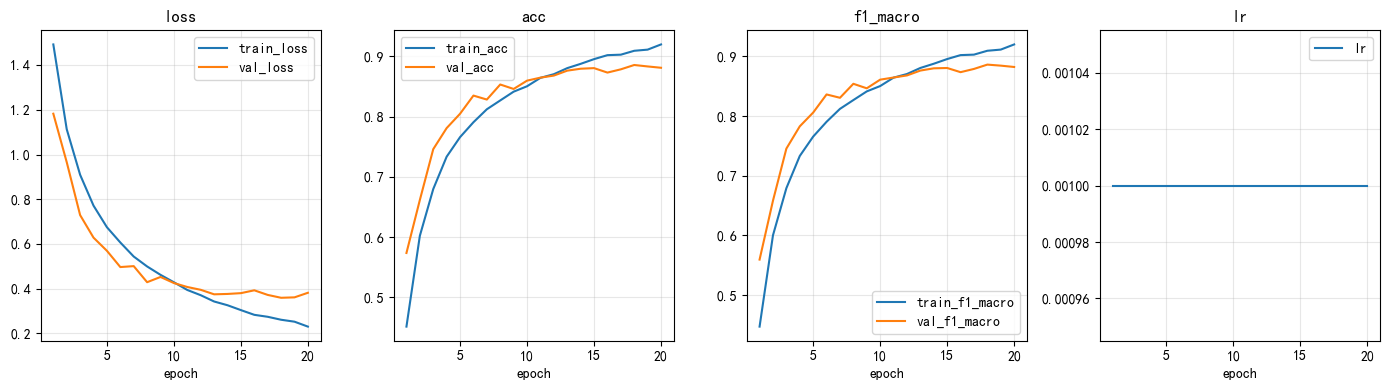

c:\DevEnv\python_venv\.any\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Final test accuracy: 0.1263


In [31]:
model = CNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)
criterion = nn.CrossEntropyLoss()

trainer = get_trainer()(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_step="plateau",
    monitor="val_loss",
    mode="min",
    patience=5,
    device=device,
)

trainer.fit(train_loader, val_loader, epochs=20)
trainer.plot_history()

test_log = trainer.evaluate(test_loader)
print(f"Final test accuracy: {test_log['acc']:.4f}")